# 단계 5 — SHAP 으로 모델 설명하기

단계 4에서 LightGBM 이 가장 성능이 좋았습니다. 하지만 LightGBM 은 트리를 300개 쌓은
모델이라 **속을 들여다볼 수 없는 '검은 상자'** 입니다.
"이 주소를 왜 사기로 판정했나?"에 답할 수 없으면 실무에서 쓸 수 없습니다.
(금융권에서는 고객에게 거절 사유를 설명할 의무가 있습니다.)

**SHAP** 은 이 검은 상자를 여는 도구입니다.

---

## SHAP 이란?

원래 게임 이론에서 나온 개념입니다.
> "여러 명이 함께 일해서 성과를 냈을 때, 각자의 공로를 어떻게 **공정하게** 나눌까?"

여기서 '선수'는 **특징(feature)**, '성과'는 **모델의 예측값**입니다.

$$
\text{예측 로짓} = \underbrace{\phi_0}_{\text{기준값}} + \phi_1 + \phi_2 + \cdots + \phi_{38}
$$

**기호 뜻**

| 기호 | 읽는 법 | 뜻 |
|---|---|---|
| $\phi_0$ | 파이 제로 | **기준값(base value)**. 아무 정보도 없을 때의 예측 = 학습 데이터 전체의 평균 로짓 |
| $\phi_j$ | 파이 제이 | $j$번째 특징의 **SHAP 값**. 이 특징이 예측을 얼마나 밀었는지 |

- $\phi_j > 0$ → 이 특징이 예측을 **사기 쪽으로** 밀었다
- $\phi_j < 0$ → **정상 쪽으로** 밀었다

이 등식이 **정확히** 성립합니다 (가법성, additivity).
그래서 "이 주소가 사기인 이유는 A 때문에 +3.7, B 때문에 +2.9..." 처럼
숫자로 딱 떨어지게 설명할 수 있습니다. 아래에서 직접 검산해 봅니다.

### 로짓(logit)이 뭔가요?

확률 $p$ 를 $-\infty \sim +\infty$ 범위로 펼친 값입니다.

$$\text{로짓} = \ln\left(\frac{p}{1-p}\right), \qquad p = \frac{1}{1+e^{-\text{로짓}}}$$

**왜 이렇게 하나?** 확률은 0~1 사이에 갇혀 있어 덧셈이 어색합니다
(0.9 + 0.2 = 1.1 은 확률이 될 수 없죠). 로짓으로 펼치면 자유롭게 더할 수 있고,
다 더한 뒤 시그모이드 함수로 확률로 되돌리면 됩니다.

| 로짓 | 확률 |
|---|---|
| −2 | 약 12% |
| 0 | 50% |
| +2 | 약 88% |
| +11.5 | 99.999% |

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import lightgbm as lgb
from sklearn.model_selection import train_test_split

from src import config, preprocessing, explain
from src.plot_style import (
    apply_project_plot_style, COLOR_NORMAL, COLOR_FRAUD, COLOR_TEXT_SECONDARY, COLOR_GRID,
)

apply_project_plot_style()
pd.set_option("display.width", 220)
config.ensure_directories_exist()
print(f"shap {shap.__version__} / lightgbm {lgb.__version__}")

shap 0.51.0 / lightgbm 4.7.0


---

## 1. 모델 학습

**no_leak 트랙**(누수를 최소한으로 차단한 데이터)으로 학습합니다.
누수를 그대로 둔 full 트랙으로 설명하면, SHAP 그림이 "표시 열 하나가 전부"라는
시시한 결과만 보여 줄 테니까요.

교차검증(단계 4)과 달리 여기서는 **한 번만 나눕니다**(학습 80% / 검증 20%).
SHAP 설명은 "이 모델이 이 데이터를 어떻게 보는가"를 보여주는 것이 목적이라
fold 마다 다른 모델을 만들면 오히려 이야기가 흩어집니다.

In [2]:
features, target, _ = preprocessing.build_modeling_dataset(preprocessing.TRACK_NO_LEAK)

# stratify=target : 나눌 때 사기 비율을 학습셋과 검증셋 양쪽에 똑같이 맞춘다
train_features, test_features, train_target, test_target = train_test_split(
    features, target,
    test_size=0.2,
    stratify=target,
    random_state=config.RANDOM_SEED,
)

lightgbm_model = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, num_leaves=31,
    random_state=config.RANDOM_SEED, verbose=-1,
)
lightgbm_model.fit(train_features, train_target)

test_probabilities = lightgbm_model.predict_proba(test_features)[:, 1]

print(f"학습셋 {len(train_features):,}행 / 검증셋 {len(test_features):,}행")
print(f"검증셋 사기 비율 {test_target.mean()*100:.1f}%")

학습셋 7,852행 / 검증셋 1,964행
검증셋 사기 비율 22.2%


---

## 2. SHAP 값 계산과 검산

`TreeExplainer` 는 트리 모델 전용 SHAP 계산기입니다.
트리 구조를 직접 훑어서 정확한 SHAP 값을 빠르게 구합니다(근사가 아닙니다).

계산 후 **"기준값 + SHAP 합계 = 예측 로짓"** 이 정말 성립하는지 검산합니다.
이걸 확인하지 않으면 설명 전체를 믿을 수 없습니다.

In [3]:
shap_explainer = shap.TreeExplainer(lightgbm_model)
shap_explanation = shap_explainer(test_features)

# shap 버전·모델에 따라 결과 모양이 달라서, 사기 클래스 기준으로 통일해 꺼낸다
shap_values, base_values = explain.extract_shap_matrix(shap_explanation)

print(f"SHAP 값 행렬 모양: {shap_values.shape}  (검증 샘플 수 x 특징 수)")
print(f"기준값(base value): {base_values[0]:.4f}")

# 기준값이 정확히 무엇인지 직접 확인한다.
# TreeExplainer 의 기준값 = '학습 데이터에 대한 모델 원시 출력(로짓)의 평균'
train_raw_logits = lightgbm_model.predict(train_features, raw_score=True)
print(f"  학습 데이터 로짓의 평균: {train_raw_logits.mean():.4f}  <- 기준값과 같아야 함")
print()
print("  참고: '평균 확률의 로짓'과는 다릅니다.")
fraud_rate = train_target.mean()
print(f"    학습 사기 비율 {fraud_rate:.4f} -> 로짓 {np.log(fraud_rate/(1-fraud_rate)):.4f}")
print("    두 값이 크게 다른 이유는 이 모델의 예측이 극단적이기 때문입니다.")
print(f"    로짓 분포(5·50·95 백분위): {np.round(np.percentile(train_raw_logits, [5, 50, 95]), 2)}")
print()

additivity_check = explain.verify_shap_additivity(shap_values, base_values, test_probabilities)
print("가법성 검산 결과:")
for key, value in additivity_check.items():
    print(f"  {key}: {value}")

SHAP 값 행렬 모양: (1964, 38)  (검증 샘플 수 x 특징 수)
기준값(base value): -4.7187
  학습 데이터 로짓의 평균: -4.7187  <- 기준값과 같아야 함

  참고: '평균 확률의 로짓'과는 다릅니다.
    학습 사기 비율 0.2220 -> 로짓 -1.2542
    두 값이 크게 다른 이유는 이 모델의 예측이 극단적이기 때문입니다.
    로짓 분포(5·50·95 백분위): [-10.71  -7.54   8.57]

가법성 검산 결과:
  최대 오차: 6.199485369506874e-12
  평균 오차: 7.891839447898638e-14
  가법성 성립: True


### 검산 통과

오차가 $10^{-12}$ 수준입니다. 컴퓨터가 소수를 다룰 때 생기는 반올림 오차일 뿐이고,
**"기준값 + SHAP 합계 = 예측 로짓" 이 정확히 성립**합니다.

### 기준값(base value)이 정확히 무엇인지

기준값이 **−4.7187** 인데, 이는 **학습 데이터에 대한 모델 출력 로짓의 평균**입니다
(위 출력에서 두 값이 정확히 일치하는 것을 확인했습니다).

흔한 오해 하나를 짚고 갑니다. 기준값은 **"평균 확률의 로짓"이 아닙니다.**

| | 값 |
|---|---|
| 학습 사기 비율 22.2% 의 로짓 | −1.25 |
| **실제 기준값 (로짓들의 평균)** | **−4.72** |

두 값이 이렇게 다른 이유는 **이 모델의 예측이 극단적**이기 때문입니다.
로짓이 −12부터 +11까지 널뛰는데, 정상으로 강하게 확신하는 주소가 많아
로짓의 평균이 크게 음수 쪽으로 끌려갑니다.
(평균을 낸 뒤 변환하는 것과, 변환한 뒤 평균을 내는 것은 다릅니다 — 옌센 부등식)

중요한 것은 **여기서 출발해 SHAP 값들을 더하면 최종 예측에 정확히 도달한다**는 점입니다.

---

## 3. 전역 설명 — 모델은 전반적으로 무엇을 보는가

중요도 = **|SHAP| 의 평균**

절댓값을 쓰는 이유: 같은 특징이라도 어떤 주소에서는 사기 쪽으로(+),
다른 주소에서는 정상 쪽으로(−) 밀 수 있습니다. 그냥 평균내면 서로 상쇄되어
0에 가까워집니다. "얼마나 **크게** 영향을 주는가"를 보려면 방향을 무시하고 크기만 봐야 합니다.

In [4]:
global_importance = explain.build_global_importance_table(
    shap_values, list(test_features.columns)
)
global_importance.head(15).round(4)

,순위,특징,평균 SHAP 크기,평균 SHAP(부호)
0,1,Unique Received From Addresses,1.1172,0.0958
1,2,avg val received,1.0317,-0.0790
2,3,Time Diff between first and last (Mins),0.9684,0.1410
3,4,total ether received,0.8203,0.0167
4,5,total transactions (including tnx to create co...,0.7643,-0.0518
5,6,ERC20 min val rec,0.6754,-0.0606
6,7,Avg min between received tnx,0.5417,-0.0591
7,8,total Ether sent,0.3627,-0.0184
8,9,Received Tnx,0.3506,-0.0582
9,10,Sent tnx,0.3366,0.0134


findfont: Failed to find font weight normal, now using 500.


findfont: Failed to find font weight normal, now using 500.


findfont: Failed to find font weight normal, now using 500.


findfont: Failed to find font weight normal, now using 500.


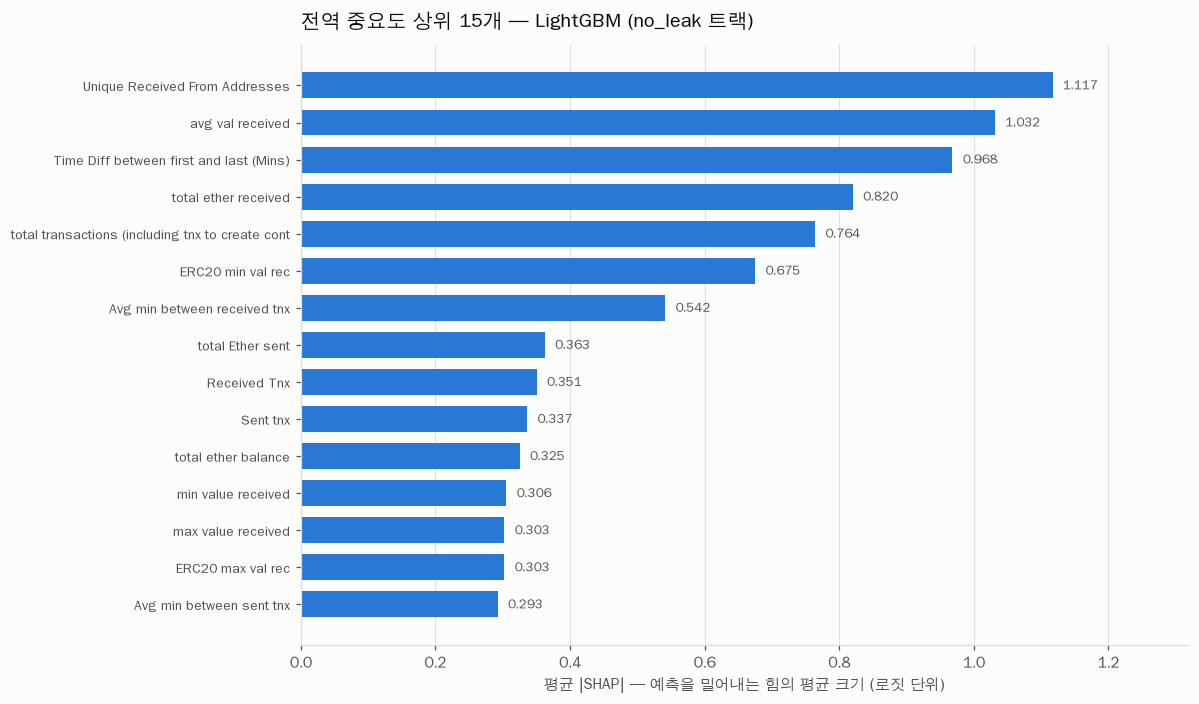

In [5]:
# ── 그림: 전역 중요도 상위 15개 ─────────────────────────────────────
# 형태 선택: 이름이 긴 항목들의 '크기 비교'이므로 가로 막대가 읽기 쉽다.
# 색은 한 가지만 쓴다 — 여기서 색이 구분해야 할 범주가 없기 때문이다(단일 계열).
top_importance = global_importance.head(15).iloc[::-1]   # 큰 값이 위로 오도록 뒤집는다

figure, axis = plt.subplots(figsize=(11, 6.5))
bar_positions = np.arange(len(top_importance))

axis.barh(bar_positions, top_importance["평균 SHAP 크기"], color=COLOR_NORMAL, height=0.7)

for position, value in zip(bar_positions, top_importance["평균 SHAP 크기"]):
    axis.text(value + 0.015, position, f"{value:.3f}",
              va="center", fontsize=8.5, color=COLOR_TEXT_SECONDARY)

axis.set_yticks(bar_positions)
axis.set_yticklabels([name[:48] for name in top_importance["특징"]], fontsize=9)
axis.set_xlabel("평균 |SHAP| — 예측을 밀어내는 힘의 평균 크기 (로짓 단위)")
axis.set_xlim(0, top_importance["평균 SHAP 크기"].max() * 1.18)
axis.set_title("전역 중요도 상위 15개 — LightGBM (no_leak 트랙)", loc="left", pad=12)
axis.grid(axis="y", visible=False)

figure.tight_layout()
figure.savefig(config.FIGURES_DIRECTORY / "06_shap_global_importance.png", dpi=150, bbox_inches="tight")
plt.show()

findfont: Failed to find font weight normal, now using 500.


findfont: Failed to find font weight normal, now using 500.


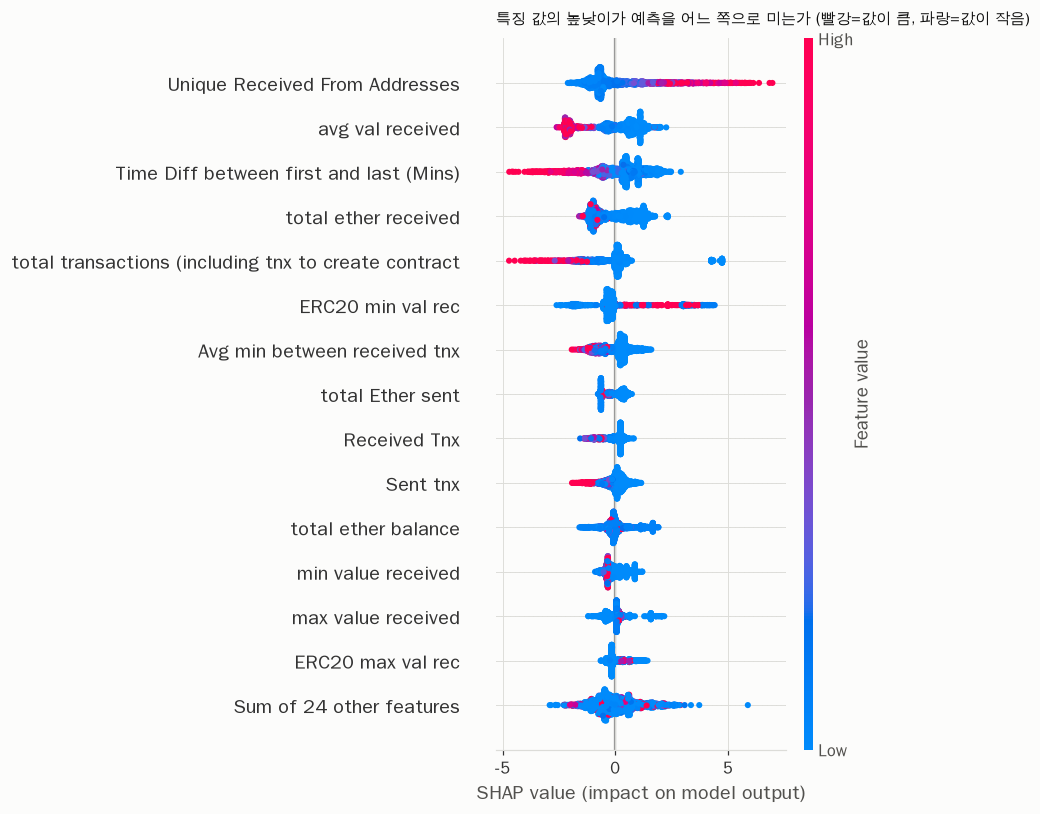

In [6]:
# ── SHAP 기본 그림(beeswarm)도 함께 본다 ────────────────────────────
# 위 막대그림은 '크기'만 보여주지만, beeswarm 은 한 가지를 더 보여준다:
#   점 하나 = 주소 하나
#   가로 위치 = 그 주소에서 이 특징의 SHAP 값 (오른쪽일수록 사기 쪽으로 밀었다)
#   점 색깔  = 그 특징의 '값'이 높은지(빨강) 낮은지(파랑)
# 그래서 "값이 높을 때 사기 쪽으로 미는가, 낮을 때 미는가"를 읽을 수 있다.
#
# 주의: 이 그림의 빨강/파랑은 SHAP 라이브러리 기본 색으로, 특징의 '값 크기'를 뜻한다.
#       이 프로젝트의 다른 그림에서 쓰는 주황(사기)/파랑(정상)과는 의미가 다르다.
plt.figure()
shap.plots.beeswarm(shap_explanation, max_display=15, show=False)
plt.title("특징 값의 높낮이가 예측을 어느 쪽으로 미는가 (빨강=값이 큼, 파랑=값이 작음)",
          fontsize=10, loc="left", pad=10)
plt.tight_layout()
plt.savefig(config.FIGURES_DIRECTORY / "07_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

### 전역 설명 해석

상위 특징들이 **거래 빈도 / 금액 / 시간 간격** 묶음에 고루 퍼져 있습니다.

| 순위 | 특징 | 묶음 |
|---|---|---|
| 1 | `Unique Received From Addresses` (서로 다른 송금인 수) | 거래 빈도 |
| 2 | `avg val received` (받은 금액 평균) | 금액 |
| 3 | `Time Diff between first and last (Mins)` (활동 기간) | 시간 간격 |
| 4 | `total ether received` (받은 총액) | 금액 |
| 5 | `total transactions` (전체 거래 수) | 거래 빈도 |

**단계 3의 IV 순위와 대체로 일치**합니다. IV 는 각 특징을 하나씩 따로 본 것이고
SHAP 은 모델이 여러 특징을 함께 쓴 결과인데도 비슷하다는 건,
이 데이터에서 특징들이 각자 독립적으로 강한 신호를 준다는 뜻입니다
(= 오염이 넓게 퍼져 있다는 단계 3의 결론과 같은 이야기입니다).

---

## 4. 개별 설명 — 이 주소 하나를 왜 그렇게 판단했나

**고르는 기준**: 모델이 **자신 있게, 그리고 정확하게** 맞힌 사례 2개
- 사기 대표: 실제 사기이면서 사기 확률이 가장 높은 주소
- 정상 대표: 실제 정상이면서 사기 확률이 가장 낮은 주소

애매한 사례는 설명도 애매합니다. "모델이 생각하는 전형적인 사기/정상"을 보려면
확신이 강한 사례가 좋습니다.

In [7]:
representative_positions = explain.pick_representative_samples(
    test_probabilities, test_target.to_numpy()
)

for label, row_position in representative_positions.items():
    print(f"{label}: 검증셋 {row_position}번째 행")
    print(f"  실제 정답 FLAG = {test_target.iloc[row_position]}")
    print(f"  예측 사기 확률 = {test_probabilities[row_position]:.6f}")

사기 대표: 검증셋 882번째 행
  실제 정답 FLAG = 1
  예측 사기 확률 = 0.999989
정상 대표: 검증셋 973번째 행
  실제 정답 FLAG = 0
  예측 사기 확률 = 0.000004


In [8]:
# 사기 대표 주소의 설명 표
fraud_position = representative_positions["사기 대표"]
fraud_table, fraud_summary = explain.build_single_explanation_table(
    shap_values, base_values, test_features, fraud_position, top_count=10
)

print("【사기 대표 주소】 기여도 상위 10개 특징\n")
print(fraud_table.round(4).to_string(index=False))
print()
for key, value in fraud_summary.items():
    print(f"  {key}: {value:.4f}")

【사기 대표 주소】 기여도 상위 10개 특징

                                     특징    이 주소의 값  SHAP 기여     방향
         Unique Received From Addresses    17.0000   3.7111 사기 쪽 ↑
                      ERC20 min val rec     1.3370   2.9447 사기 쪽 ↑
Time Diff between first and last (Mins) 13996.5700   1.6901 사기 쪽 ↑
                           min val sent    16.5161   1.2550 사기 쪽 ↑
                       avg val received     0.8693   1.2409 사기 쪽 ↑
           Avg min between received tnx    88.3800   1.0182 사기 쪽 ↑
                               Sent tnx     1.0000   0.8028 사기 쪽 ↑
                   total ether received    16.5169   0.7569 사기 쪽 ↑
                     min value received     0.0000   0.5649 사기 쪽 ↑
                      ERC20 max val rec     1.3370   0.5358 사기 쪽 ↑

  기준값(base value): -4.7187
  SHAP 합계: 16.1804
  최종 로짓: 11.4617
  최종 사기 확률: 1.0000


In [9]:
# 정상 대표 주소의 설명 표
normal_position = representative_positions["정상 대표"]
normal_table, normal_summary = explain.build_single_explanation_table(
    shap_values, base_values, test_features, normal_position, top_count=10
)

print("【정상 대표 주소】 기여도 상위 10개 특징\n")
print(normal_table.round(4).to_string(index=False))
print()
for key, value in normal_summary.items():
    print(f"  {key}: {value:.4f}")

【정상 대표 주소】 기여도 상위 10개 특징

                                                  특징     이 주소의 값  SHAP 기여     방향
             Time Diff between first and last (Mins) 769536.5000  -1.8067 정상 쪽 ↓
                                   ERC20 min val rec      0.1285  -1.7129 정상 쪽 ↓
                      Unique Received From Addresses      1.0000  -1.3694 정상 쪽 ↓
total transactions (including tnx to create contract    114.0000  -1.2084 정상 쪽 ↓
                                        Received Tnx    100.0000  -1.0897 정상 쪽 ↓
                        Avg min between received tnx   7476.4100  -0.6670 정상 쪽 ↓
                                    avg val received      0.2071   0.5419 사기 쪽 ↑
                                  max value received      0.4006  -0.3918 정상 쪽 ↓
                                  min value received      0.2000  -0.2059 정상 쪽 ↓
                            Avg min between sent tnx   1564.0000   0.1978 사기 쪽 ↑

  기준값(base value): -4.7187
  SHAP 합계: -7.7927
  최종 로짓: -12.5114
  최종 사기 확률: 0.0000

findfont: Failed to find font weight normal, now using 500.


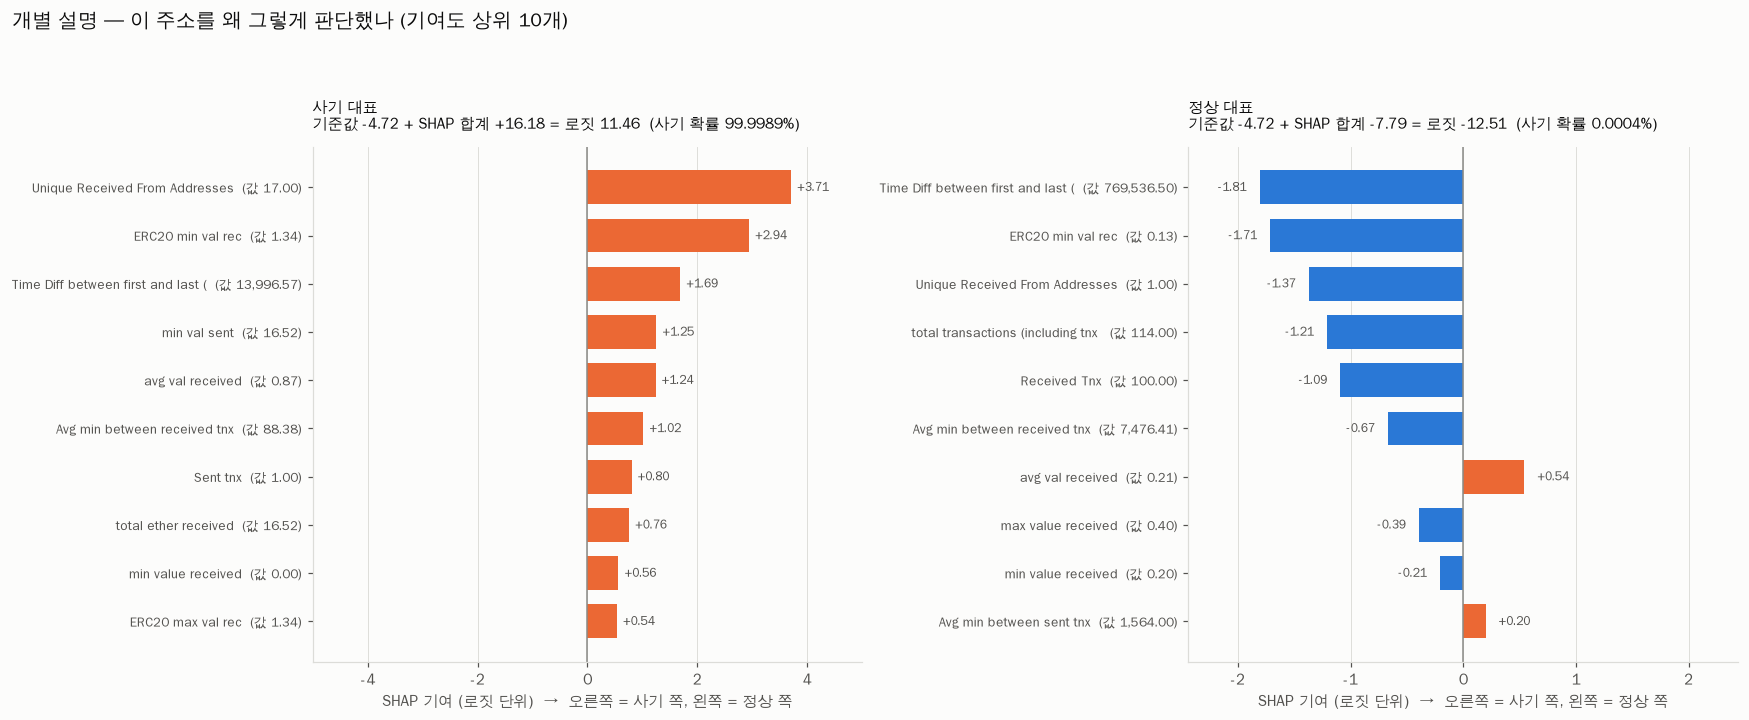

In [10]:
# ── 그림: 개별 설명 2개를 나란히 ────────────────────────────────────
# 형태 선택: '기준값에서 출발해 각 특징이 얼마나 밀었는지'의 누적이므로
#            0 을 기준으로 좌우로 뻗는 가로 막대가 맞다.
# 색: 이 프로젝트 공통 규약 그대로 — 주황=사기 쪽, 파랑=정상 쪽
figure, axes = plt.subplots(1, 2, figsize=(16, 6.5))

for axis, (label, table, summary) in zip(
    axes,
    [("사기 대표", fraud_table, fraud_summary), ("정상 대표", normal_table, normal_summary)],
):
    plot_table = table.iloc[::-1]   # 영향이 큰 것이 위로 오도록
    bar_positions = np.arange(len(plot_table))
    bar_colors = [
        COLOR_FRAUD if contribution > 0 else COLOR_NORMAL
        for contribution in plot_table["SHAP 기여"]
    ]

    axis.barh(bar_positions, plot_table["SHAP 기여"], color=bar_colors, height=0.7)
    axis.axvline(0, color="#8a8a86", linewidth=1.0)

    # 특징 이름 옆에 '이 주소의 실제 값'을 함께 보여준다.
    # SHAP 값만 보면 "왜 그렇게 밀었는지" 알 수 없기 때문이다.
    tick_labels = [
        f"{name[:34]}  (값 {value:,.2f})"
        for name, value in zip(plot_table["특징"], plot_table["이 주소의 값"])
    ]
    axis.set_yticks(bar_positions)
    axis.set_yticklabels(tick_labels, fontsize=8.5)

    # 막대 끝에 기여도 숫자를 직접 표시
    for position, contribution in zip(bar_positions, plot_table["SHAP 기여"]):
        offset = 0.12 if contribution > 0 else -0.12
        axis.text(contribution + offset, position, f"{contribution:+.2f}",
                  va="center", ha="left" if contribution > 0 else "right",
                  fontsize=8, color=COLOR_TEXT_SECONDARY)

    axis.set_xlabel("SHAP 기여 (로짓 단위)  →  오른쪽 = 사기 쪽, 왼쪽 = 정상 쪽")
    axis.set_title(
        f"{label}\n"
        f"기준값 {summary['기준값(base value)']:.2f} "
        f"+ SHAP 합계 {summary['SHAP 합계']:+.2f} "
        f"= 로짓 {summary['최종 로짓']:.2f}  "
        f"(사기 확률 {summary['최종 사기 확률']*100:.4f}%)",
        loc="left", fontsize=10, pad=12,
    )
    axis.grid(axis="y", visible=False)
    # 숫자 라벨이 잘리지 않도록 가로 여유를 준다
    span = max(abs(plot_table["SHAP 기여"].min()), abs(plot_table["SHAP 기여"].max()))
    axis.set_xlim(-span * 1.35, span * 1.35)

figure.suptitle(
    "개별 설명 — 이 주소를 왜 그렇게 판단했나 (기여도 상위 10개)",
    fontsize=13, x=0.01, ha="left", y=1.0,
)
figure.tight_layout(rect=[0, 0, 1, 0.95])
figure.savefig(config.FIGURES_DIRECTORY / "08_shap_individual.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 5. "사기 주소는 왜 사기로 보이나" — 한국어 3문장 요약

In [11]:
# 요약을 쓰기 전에, 이 주소의 값이 '보통 주소와 얼마나 다른지' 숫자로 확인한다.
comparison_features = [
    "Time Diff between first and last (Mins)",
    "Unique Received From Addresses",
    "avg val received",
    "Sent tnx",
    "total ether received",
]

comparison_table = pd.DataFrame({
    "정상 주소 중앙값": features[target == 0][comparison_features].median(),
    "사기 주소 중앙값": features[target == 1][comparison_features].median(),
    "이 사기 대표 주소": test_features.iloc[fraud_position][comparison_features],
    "이 정상 대표 주소": test_features.iloc[normal_position][comparison_features],
}).round(2)

# 분(minute)을 일(day)로도 보여준다 — 116,874분이 며칠인지 바로 안 와닿기 때문
활동기간_행 = "Time Diff between first and last (Mins)"
print("활동 기간을 '일' 단위로 환산:")
for column_name in comparison_table.columns:
    minutes = comparison_table.loc[활동기간_행, column_name]
    print(f"  {column_name}: {minutes:,.0f}분 = 약 {minutes/60/24:.1f}일")
print()
comparison_table

활동 기간을 '일' 단위로 환산:
  정상 주소 중앙값: 116,874분 = 약 81.2일
  사기 주소 중앙값: 7,545분 = 약 5.2일
  이 사기 대표 주소: 13,997분 = 약 9.7일
  이 정상 대표 주소: 769,536분 = 약 534.4일



,정상 주소 중앙값,사기 주소 중앙값,이 사기 대표 주소,이 정상 대표 주소
Time Diff between first and last (Mins),116874.32,7545.43,13996.57,769536.50
Unique Received From Addresses,2.00,3.00,17.00,1.00
avg val received,3.75,0.50,0.87,0.21
Sent tnx,3.00,1.00,1.00,14.00
total ether received,71.67,1.68,16.52,20.71


### 📌 3문장 요약

> **1.** 이 사기 주소는 **활동 기간이 약 9.7일**로, 정상 주소의 중앙값(약 81일)에 비해
> 8분의 1도 안 될 만큼 짧게 열렸다 닫혔습니다 — SHAP 기여 **+1.69**.
>
> **2.** 그 짧은 기간에 **서로 다른 17곳**에서 돈을 받았는데(정상 주소 중앙값은 2곳),
> 받은 금액은 건당 평균 **0.87 ETH**로 소액이고, 내보낸 거래는 **단 1건**뿐입니다
> — SHAP 기여 각각 **+3.71**, **+1.24**, **+0.80**.
>
> **3.** 정리하면 **"짧게 열어서 여러 사람에게 조금씩 긁어모으고 사라지는"** 패턴이며,
> 이는 피싱 사이트로 유인해 소액을 받아내는 수집용 지갑의 전형적인 모습입니다.

**대조군인 정상 대표 주소**는 정반대입니다: 활동 기간 **약 534일(1년 반)**,
전체 거래 **114건**, 받은 거래 **100건**을 한 상대와 꾸준히 주고받았습니다.
"오래, 꾸준히, 적은 상대와" — SHAP 이 모두 정상 쪽(−)으로 밀었습니다.

---

### ⚠️ 다만 이 해석을 그대로 믿으면 안 됩니다

위 이야기는 **그럴듯하고 실제 피싱 지갑의 알려진 패턴과도 맞습니다.**
하지만 단계 2·3에서 확인했듯 이 데이터는 정상 주소와 사기 주소를
**서로 다른 방식으로 수집해 합친 것**입니다.

그래서 "사기라서 활동 기간이 짧다"가 아니라
**"사기 주소 목록을 수집한 시점이 최근이라 활동 기간이 짧게 기록됐다"** 일 수도 있습니다.
둘을 구분하려면 **같은 시점·같은 방법으로 수집된 정상/사기 데이터**가 필요합니다 — **확인 필요**.

SHAP 은 "모델이 무엇을 보고 판단했는가"는 정확히 알려주지만,
**"그것이 진짜 인과관계인가"는 알려주지 않습니다.** 이 구분이 중요합니다.

---

## 6. 모델이 누수 신호에 의존하고 있나?

단계 3에서 찾은 **껍데기 행**(모든 특징이 0인데 100% 사기)을
모델이 실제로 이용하고 있는지 SHAP 으로 확인합니다.

In [12]:
# 검증셋에서 껍데기 행을 찾는다
empty_row_mask = (test_features == 0).all(axis=1).to_numpy()
print(f"검증셋의 껍데기 행: {empty_row_mask.sum()}개 "
      f"(그중 실제 사기 {int(test_target.to_numpy()[empty_row_mask].sum())}개)")

if empty_row_mask.sum() > 0:
    print(f"모델이 예측한 사기 확률 평균: {test_probabilities[empty_row_mask].mean():.4f}")
    print(f"나머지 행의 사기 확률 평균  : {test_probabilities[~empty_row_mask].mean():.4f}")
    print()

    # 껍데기 행에서 어떤 특징이 사기 쪽으로 밀고 있는지 확인
    empty_row_shap = shap_values[empty_row_mask]
    empty_contribution = pd.DataFrame({
        "특징": test_features.columns,
        "껍데기 행 평균 SHAP": empty_row_shap.mean(axis=0),
        "전체 평균 SHAP": shap_values.mean(axis=0),
    })
    empty_contribution = empty_contribution.reindex(
        empty_contribution["껍데기 행 평균 SHAP"].abs().sort_values(ascending=False).index
    ).head(8).reset_index(drop=True)
    print("껍데기 행에서 예측을 가장 크게 민 특징:")
    print(empty_contribution.round(4).to_string(index=False))

검증셋의 껍데기 행: 58개 (그중 실제 사기 58개)
모델이 예측한 사기 확률 평균: 0.9998
나머지 행의 사기 확률 평균  : 0.1851

껍데기 행에서 예측을 가장 크게 민 특징:
                                                  특징  껍데기 행 평균 SHAP  전체 평균 SHAP
total transactions (including tnx to create contract         4.7435     -0.0518
                                 total ether balance         1.6716      0.0179
                                  max value received         1.5818     -0.0101
                                total ether received         1.2567      0.0167
                                    avg val received         1.1025     -0.0790
             Time Diff between first and last (Mins)         1.0134      0.1410
                                  min value received         0.8720     -0.0441
                      Unique Received From Addresses        -0.5300      0.0958


### 확인 결과 — 누수 의존이 SHAP 에 그대로 드러났습니다

검증셋의 껍데기 행 **58개는 전부 사기**였고, 모델은 이들에게
**평균 사기 확률 0.9998** 을 줬습니다 (나머지 행은 평균 0.185).

어떤 특징이 그렇게 밀었는지 보면 결정적입니다:

| 특징 | 껍데기 행 평균 SHAP | 전체 평균 SHAP |
|---|---|---|
| `total transactions (...)` | **+4.74** | −0.05 |
| `total ether balance` | +1.67 | +0.02 |
| `max value received` | +1.58 | −0.01 |

`total transactions` 는 전체적으로는 예측을 살짝 **정상 쪽**(−0.05)으로 미는 특징인데,
껍데기 행에서만 **+4.74** 로 정반대 방향으로 강하게 밉니다.
**"거래 수가 0이면 사기"** 라는 규칙을 모델이 실제로 학습했다는 뜻입니다.

이것이 단계 3에서 예상한 **잔여 누수**이며, SHAP 으로 눈에 보이게 확인됐습니다.

> **이 절의 요점**: 데이터 문제를 의심했을 때 SHAP 으로 **검증할 수 있다**는 것입니다.
> "성능이 너무 좋다 → 누수를 의심 → SHAP 으로 어떤 특징이 범인인지 특정"
> 이 흐름이 실무에서 그대로 쓰입니다.

---

## 7. 보고서 저장

In [13]:
lines = ["# SHAP 설명 보고서", ""]
lines.append('LightGBM(no_leak 트랙)에 SHAP 을 적용해 “모델이 무엇을 보고 판단했는지” 정리한 문서입니다.')
lines.append("")
lines.append("## SHAP 의 기본 등식")
lines.append("")
lines.append("```")
lines.append("예측 로짓 = 기준값(base value) + SHAP_1 + SHAP_2 + ... + SHAP_38")
lines.append("```")
lines.append("")
lines.append(f"- 기준값 = **{base_values[0]:.4f}** (학습 데이터에 대한 모델 출력 로짓의 평균)")
lines.append(f"- 가법성 검산: 최대 오차 **{additivity_check['최대 오차']:.2e}** -> 등식이 정확히 성립")
lines.append("")
lines.append("> 기준값은 '평균 확률의 로짓'(-1.25)이 **아닙니다**. 이 모델의 예측이 극단적이라")
lines.append("> 로짓들의 평균이 크게 음수 쪽으로 끌려간 것입니다.")
lines.append("")
lines.append("---")
lines.append("")
lines.append("## 1. 전역 중요도 상위 15개")
lines.append("")
lines.append('중요도 = SHAP 값의 **절댓값 평균**입니다. 절댓값을 쓰는 이유는 방향이 서로 상쇄되지 않게 하기 위해서입니다.')
lines.append("")
lines.append(global_importance.head(15).round(4).to_markdown(index=False))
lines.append("")
lines.append("![전역 중요도](figures/06_shap_global_importance.png)")
lines.append("")
lines.append("![beeswarm](figures/07_shap_beeswarm.png)")
lines.append("")
lines.append("---")
lines.append("")
lines.append("## 2. 개별 설명")
lines.append("")
lines.append("![개별 설명](figures/08_shap_individual.png)")
lines.append("")

for label, table, summary, position in [
    ("사기 대표 주소", fraud_table, fraud_summary, fraud_position),
    ("정상 대표 주소", normal_table, normal_summary, normal_position),
]:
    lines.append(f"### {label}")
    lines.append("")
    lines.append(f"- 실제 정답: `FLAG = {test_target.iloc[position]}`")
    lines.append(f"- 예측 사기 확률: **{test_probabilities[position]:.6f}**")
    lines.append(f"- 기준값 {summary['기준값(base value)']:.4f} "
                 f"+ SHAP 합계 {summary['SHAP 합계']:+.4f} "
                 f"= 로짓 {summary['최종 로짓']:.4f}")
    lines.append("")
    lines.append(table.round(4).to_markdown(index=False))
    lines.append("")

lines.append("---")
lines.append("")
lines.append('## 3. “사기 주소는 왜 사기로 보이나” — 3문장 요약')
lines.append("")
lines.append("1. 이 사기 주소는 **활동 기간이 약 9.7일**로, 정상 주소의 중앙값(약 81일)에 비해")
lines.append("   8분의 1도 안 될 만큼 짧게 열렸다 닫혔습니다 (SHAP 기여 +1.69).")
lines.append("2. 그 짧은 기간에 **서로 다른 17곳**에서 돈을 받았는데(정상 주소 중앙값은 2곳),")
lines.append("   받은 금액은 건당 평균 **0.87 ETH** 로 소액이고 내보낸 거래는 **단 1건**뿐입니다")
lines.append("   (SHAP 기여 각각 +3.71, +1.24, +0.80).")
lines.append('3. 정리하면 **“짧게 열어서 여러 사람에게 조금씩 긁어모으고 사라지는”** 패턴이며,')
lines.append("   피싱 사이트로 유인해 소액을 받아내는 수집용 지갑의 전형적인 모습입니다.")
lines.append("")
lines.append("### 비교표")
lines.append("")
lines.append(comparison_table.to_markdown())
lines.append("")
lines.append("### 이 해석의 한계 (확인 필요)")
lines.append("")
lines.append('위 이야기는 실제 피싱 지갑의 알려진 패턴과 맞지만, 이 데이터는 정상 주소와 사기 주소를')
lines.append('**서로 다른 방식으로 수집해 합친 것**입니다. 따라서 “사기라서 활동 기간이 짧다”가 아니라')
lines.append('“사기 주소를 수집한 시점이 최근이라 짧게 기록됐다” 일 수도 있습니다.')
lines.append("둘을 구분하려면 같은 시점·같은 방법으로 수집된 데이터가 필요합니다.")
lines.append("")
lines.append('**SHAP 은 “모델이 무엇을 보는가”는 정확히 알려주지만, “그것이 진짜 원인인가”는 알려주지 않습니다.**')
lines.append("")
lines.append("---")
lines.append("")
lines.append("## 4. 모델이 누수 신호에 의존하는가 — SHAP 으로 확인")
lines.append("")
lines.append(f"검증셋의 껍데기 행(모든 특징이 0) **{int(empty_row_mask.sum())}개는 전부 사기**였고,")
lines.append(f"모델은 이들에게 평균 사기 확률 **{test_probabilities[empty_row_mask].mean():.4f}** 를 줬습니다")
lines.append(f"(나머지 행은 평균 {test_probabilities[~empty_row_mask].mean():.4f}).")
lines.append("")
lines.append(empty_contribution.round(4).to_markdown(index=False))
lines.append("")
lines.append("`total transactions` 는 전체적으로는 예측을 살짝 **정상 쪽**으로 미는 특징인데,")
lines.append("껍데기 행에서만 **정반대 방향으로 강하게** 밉니다.")
lines.append('**“거래 수가 0이면 사기”** 라는 규칙을 모델이 실제로 학습했다는 뜻입니다.')
lines.append("")

output_path = config.REPORTS_DIRECTORY / "shap_summary.md"
output_path.write_text(chr(10).join(lines), encoding="utf-8")
print(f"저장 완료: {output_path}")

저장 완료: /home/user/blockchain/reports/shap_summary.md


---

## 8. 단계 5 요약

**만든 것**

- `src/explain.py` — SHAP 값 추출, 가법성 검산, 전역·개별 설명 표 생성
- `reports/figures/06_shap_global_importance.png` — 전역 중요도 상위 15개
- `reports/figures/07_shap_beeswarm.png` — 특징 값의 높낮이가 미는 방향
- `reports/figures/08_shap_individual.png` — 사기 1건·정상 1건 개별 설명
- `reports/shap_summary.md` — 위 내용을 정리한 보고서

**배운 것**

1. SHAP 은 "기준값 + 각 특징의 기여 = 예측"이라는 **정확한 등식**을 준다 (오차 $10^{-12}$)
2. 전역 중요도는 단계 3의 IV 순위와 **대체로 일치**했다
3. 개별 설명으로 "이 주소가 왜 사기인지"를 **숫자와 함께 문장으로** 만들 수 있다
4. SHAP 은 **"모델이 무엇을 보는가"** 는 알려주지만
   **"그것이 진짜 원인인가"** 는 알려주지 않는다

**다음 단계(6)**: 사기를 놓치는 비용과 정상 고객을 오탐하는 비용이 다를 때
임계값(cut-off)을 어떻게 골라야 하는지 표로 정리합니다.